In [1]:
from utils import *

NOTEBOOK_ID = '13'

In [ ]:
def remove_outliers(df, col, lower=0.01, upper=0.99):
    low_val = df[col].quantile(lower)
    high_val = df[col].quantile(upper)
    return df[(df[col] >= low_val) & (df[col] <= high_val)]

all_ludwig_df = pd.read_excel(f'{METADATA_DIR}/1-s2.0-S2405471223001527-mmc2.xlsx',sheet_name='vTR-CoV Tiling Activation')
all_ludwig_df = remove_outliers(all_ludwig_df,'Avg')
all_ludwig_df['mean_scaled'] = StandardScaler().fit_transform(all_ludwig_df['Avg'].to_numpy().reshape(-1,1))

all_entrapseq_df = pd.read_csv(f'{EXPERIMENT_DIR}/experimental_data.csv')
all_entrapseq_df['ratio_mean'] = all_entrapseq_df[['ratio_rep1','ratio_rep2']].mean(axis=1)
all_entrapseq_df = remove_outliers(all_entrapseq_df, 'ratio_mean')
all_entrapseq_df['mean_scaled'] = StandardScaler().fit_transform(all_entrapseq_df['ratio_mean'].to_numpy().reshape(-1,1))

print(f"ENTRAP-seq all libraries dynamic range: {all_entrapseq_df['mean_scaled'].max() - all_entrapseq_df['mean_scaled'].min():.3f}")
print(f"Ludwig et al. all libraries dynamic range: {all_ludwig_df['mean_scaled'].max() - all_ludwig_df['mean_scaled'].min():.3f}")

df = pd.read_excel(f'{METADATA_DIR}/1-s2.0-S2405471223001527-mmc2.xlsx',sheet_name='vTR-CoV Tiling Activation').dropna(subset='Library')
ludwig_df = None
for dataset in df['Library'].unique():
    tmp_df = df.query(f'Library == "{dataset}"').copy()
    tmp_df = remove_outliers(tmp_df, 'Avg')
    tmp_df['mean_scaled'] = StandardScaler().fit_transform(tmp_df['Avg'].to_numpy().reshape(-1,1))
    ludwig_df = pd.concat([ludwig_df, tmp_df]).reset_index(drop=True)

for dataset in ludwig_df['Library'].unique():
    tmp_df = ludwig_df.query(f'Library == "{dataset}"')
    print(f"Ludwig et al. {dataset} dynamic range: {tmp_df['mean_scaled'].max() - tmp_df['mean_scaled'].min():.3f}")

df = pd.read_csv(f'{EXPERIMENT_DIR}/experimental_data.csv')
entrapseq_df = None
for dataset in df['dataset'].unique():
    tmp_df = df.query(f'dataset == "{dataset}"').copy()
    tmp_df['ratio_mean'] = tmp_df[['ratio_rep1','ratio_rep2']].mean(axis=1)
    tmp_df = remove_outliers(tmp_df, 'ratio_mean')
    tmp_df['mean_scaled'] = StandardScaler().fit_transform(tmp_df['ratio_mean'].to_numpy().reshape(-1,1))
    entrapseq_df = pd.concat([entrapseq_df, tmp_df]).reset_index(drop=True)

for dataset in df['dataset'].unique():
    tmp_df = entrapseq_df.query(f'dataset == "{dataset}"')
    print(f"ENTRAP-seq {dataset} library dynamic range: {tmp_df['mean_scaled'].max() - tmp_df['mean_scaled'].min():.3f}")

ENTRAP-seq all libraries dynamic range: 5.842
Ludwig et al. all libraries dynamic range: 4.849
Ludwig et al. vTR_census dynamic range: 5.468
Ludwig et al. coronavirus dynamic range: 5.086
ENTRAP-seq 500 library dynamic range: 5.553
ENTRAP-seq 250 library dynamic range: 5.083
ENTRAP-seq 1K library dynamic range: 5.485
ENTRAP-seq 2K library dynamic range: 6.131


/tmp/ipykernel_1438090/1037907370.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("Blues")


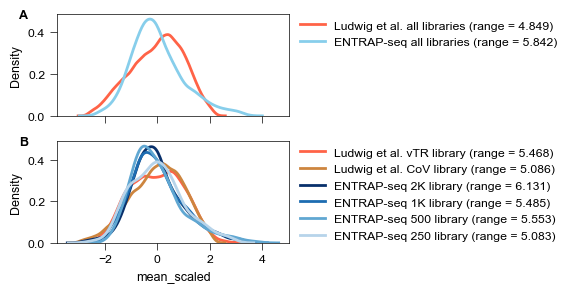

In [9]:
n_colors = 4  
cmap = cm.get_cmap("Blues")
sample_points = np.linspace(0.3, 1.0, n_colors)
colors = [cmap(p) for p in sample_points]
palette = [mcolors.to_hex(c) for c in colors]
palette = palette[::-1]

fig, axes = plt.subplots(nrows=2,ncols=1,figsize=(6,3),sharex=True)

g = sns.kdeplot(data=all_ludwig_df,x='mean_scaled',linewidth=2,color='tomato',label=f'Ludwig et al. all libraries (range = {all_ludwig_df["mean_scaled"].max() - all_ludwig_df["mean_scaled"].min():.3f})',ax=axes[0])
sns.kdeplot(data=all_entrapseq_df,x='mean_scaled',linewidth=2,color='skyblue',label=f'ENTRAP-seq all libraries (range = {all_entrapseq_df["mean_scaled"].max() - all_entrapseq_df["mean_scaled"].min():.3f})',ax=axes[0])
g.legend(frameon=False,bbox_to_anchor=(1.0,1.05),loc='upper left')
g.set(xlabel='Ratio')

tmp_df = ludwig_df.query('Library == "vTR_census"')
g = sns.kdeplot(data=tmp_df,x='mean_scaled',linewidth=2,color='tomato',label=f'Ludwig et al. vTR library (range = {tmp_df["mean_scaled"].max() - tmp_df["mean_scaled"].min():.3f})',ax=axes[1])
tmp_df = ludwig_df.query('Library == "coronavirus"')
g = sns.kdeplot(data=tmp_df,x='mean_scaled',linewidth=2,color='peru',label=f'Ludwig et al. CoV library (range = {tmp_df["mean_scaled"].max() - tmp_df["mean_scaled"].min():.3f})',ax=axes[1])
tmp_df = entrapseq_df.query('dataset == "2K"')
sns.kdeplot(data=tmp_df,x='mean_scaled',linewidth=2,color=palette[0],label=f'ENTRAP-seq 2K library (range = {tmp_df["mean_scaled"].max() - tmp_df["mean_scaled"].min():.3f})',ax=axes[1])
tmp_df = entrapseq_df.query('dataset == "1K"')
sns.kdeplot(data=tmp_df,x='mean_scaled',linewidth=2,color=palette[1],label=f'ENTRAP-seq 1K library (range = {tmp_df["mean_scaled"].max() - tmp_df["mean_scaled"].min():.3f})',ax=axes[1])
tmp_df = entrapseq_df.query('dataset == "500"')
sns.kdeplot(data=tmp_df,x='mean_scaled',linewidth=2,color=palette[2],label=f'ENTRAP-seq 500 library (range = {tmp_df["mean_scaled"].max() - tmp_df["mean_scaled"].min():.3f})',ax=axes[1])
tmp_df = entrapseq_df.query('dataset == "250"')
sns.kdeplot(data=tmp_df,x='mean_scaled',linewidth=2,color=palette[3],label=f'ENTRAP-seq 250 library (range = {tmp_df["mean_scaled"].max() - tmp_df["mean_scaled"].min():.3f})',ax=axes[1])
g.legend(frameon=False,bbox_to_anchor=(1.0,1.05),loc='upper left')

labels = ["A", "B"]
for ax, label in zip(axes, labels):
    ax.text(-0.125, 1.05, label, transform=ax.transAxes,
            fontsize=9, fontweight='bold', va='top', ha='right')

plt.tight_layout()

plt.savefig(f'{FIGURE_DIR}/{NOTEBOOK_ID}-dynamic_range_zscore.png',bbox_inches='tight',transparent=False,dpi=800)